# PnP-ADMM Super-Resolution Training Notebook
## Part 1: Train DnCNN Denoiser on DIV2K Dataset

This notebook:
- Trains a TinyDnCNN denoiser on grayscale DIV2K patches
- Saves the trained model weights
- Can be used as a prior for super-resolution tasks

**Required Kaggle Dataset:** DIV2K Dataset (joe1995/div2k-dataset)

In [20]:
# ============================================================
# 1. Imports and Setup
# ============================================================

import os
import glob
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from skimage import io, color, img_as_float
from skimage.metrics import peak_signal_noise_ratio as psnr

print("✓ All imports successful")

✓ All imports successful


In [21]:
# ============================================================
# 2. Reproducibility and Device
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla P100-PCIE-16GB


In [22]:
# ============================================================
# 3. Training Configuration
# ============================================================

# Dataset path - update if your DIV2K path is different
DIV2K_HR_DIR = "/kaggle/input/div2k-dataset/DIV2K_train_HR/DIV2K_train_HR"

# Output model path
WEIGHTS_PATH = "/kaggle/working/dncnn_denoiser_div2k.pth"

# Training settings
MAX_TRAIN_IMAGES = 200      # Use 200 images for faster training (full: 800)
EPOCHS = 10                 # Number of training epochs
BATCH_SIZE = 32             # Batch size
LEARNING_RATE = 1e-3        # Initial learning rate
PATCH_SIZE = 64             # Training patch size
PATCHES_PER_IMAGE = 20      # Patches extracted per image

# Model architecture
MODEL_FEATURES = 64         # Number of features in DnCNN
MODEL_DEPTH = 6             # Number of conv layers

# Noise range for training
SIGMA_MIN = 0.01
SIGMA_MAX = 0.08

print("Configuration loaded")
print(f"  Training images: {MAX_TRAIN_IMAGES}")
print(f"  Total patches: {MAX_TRAIN_IMAGES * PATCHES_PER_IMAGE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")

Configuration loaded
  Training images: 200
  Total patches: 4000
  Epochs: 10
  Batch size: 32


In [23]:
# ============================================================
# 4. Utility Functions
# ============================================================

def is_image_file(path):
    """Check if path is a valid image file"""
    valid_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}
    return os.path.isfile(path) and os.path.splitext(path)[1].lower() in valid_exts


def collect_images_from_folder(folder_path):
    """Recursively collect all image files from folder"""
    valid_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}
    image_paths = []

    for root, _, files in os.walk(folder_path):
        for fname in files:
            ext = os.path.splitext(fname)[1].lower()
            if ext in valid_exts:
                image_paths.append(os.path.join(root, fname))

    return sorted(image_paths)


def read_image_gray(path):
    """Read image and convert to grayscale float32 [0, 1]"""
    img = io.imread(path)

    if img.ndim == 2:
        gray = img_as_float(img).astype(np.float32)
    elif img.ndim == 3:
        if img.shape[2] == 4:
            img = color.rgba2rgb(img)
        gray = color.rgb2gray(img)
        gray = img_as_float(gray).astype(np.float32)
    else:
        raise ValueError(f"Unsupported image shape: {img.shape}")

    return np.clip(gray, 0.0, 1.0)


print("✓ Utility functions loaded")

✓ Utility functions loaded


In [24]:
# ============================================================
# 5. DnCNN Model Definition
# ============================================================

class TinyDnCNN(nn.Module):
    """Lightweight DnCNN for grayscale denoising"""
    def __init__(self, channels=1, features=64, depth=6):
        super().__init__()
        layers = []
        
        # First layer
        layers.append(nn.Conv2d(channels, features, kernel_size=3, padding=1))
        layers.append(nn.ReLU(inplace=True))

        # Middle layers
        for _ in range(depth):
            layers.append(nn.Conv2d(features, features, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(features))
            layers.append(nn.ReLU(inplace=True))

        # Final layer
        layers.append(nn.Conv2d(features, channels, kernel_size=3, padding=1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # Residual learning: predict noise and subtract
        return x - self.net(x)


# Create model
model = TinyDnCNN(channels=1, features=MODEL_FEATURES, depth=MODEL_DEPTH).to(device)
print(f"✓ Model created with {sum(p.numel() for p in model.parameters()):,} parameters")

✓ Model created with 223,553 parameters


In [25]:
# ============================================================
# 6. DIV2K Dataset Class
# ============================================================

class DIV2KGrayDataset(Dataset):
    """DIV2K grayscale patch dataset for denoising"""
    def __init__(
        self,
        image_paths,
        patch_size=64,
        patches_per_image=20,
        sigma_range=(0.01, 0.08),
        augment=True
    ):
        self.image_paths = image_paths
        self.patch_size = patch_size
        self.patches_per_image = patches_per_image
        self.sigma_range = sigma_range
        self.augment = augment

        # Create samples list (repeat each image path)
        self.samples = []
        for path in self.image_paths:
            for _ in range(self.patches_per_image):
                self.samples.append(path)

    def __len__(self):
        return len(self.samples)

    def _read_gray(self, path):
        return read_image_gray(path)

    def _augment(self, patch):
        """Random flips and rotations"""
        mode = random.randint(0, 7)
        if mode == 0:
            return patch
        elif mode == 1:
            return np.flipud(patch)
        elif mode == 2:
            return np.fliplr(patch)
        elif mode == 3:
            return np.rot90(patch, 1)
        elif mode == 4:
            return np.rot90(patch, 2)
        elif mode == 5:
            return np.rot90(patch, 3)
        elif mode == 6:
            return np.flipud(np.rot90(patch, 1))
        else:
            return np.fliplr(np.rot90(patch, 1))

    def __getitem__(self, idx):
        path = self.samples[idx]
        img = self._read_gray(path)

        p = self.patch_size
        h, w = img.shape

        # Pad if image is too small
        if h < p or w < p:
            pad_h = max(0, p - h)
            pad_w = max(0, p - w)
            img = np.pad(img, ((0, pad_h), (0, pad_w)), mode="reflect")
            h, w = img.shape

        # Random crop
        r = np.random.randint(0, h - p + 1)
        c = np.random.randint(0, w - p + 1)
        clean = img[r:r+p, c:c+p]

        # Augmentation
        if self.augment:
            clean = self._augment(clean).copy()

        # Add random noise
        sigma = np.random.uniform(*self.sigma_range)
        noisy = clean + np.random.randn(*clean.shape).astype(np.float32) * sigma
        noisy = np.clip(noisy, 0.0, 1.0)

        # Convert to tensors
        clean_t = torch.from_numpy(clean).unsqueeze(0).float()
        noisy_t = torch.from_numpy(noisy).unsqueeze(0).float()

        return noisy_t, clean_t


print("✓ Dataset class defined")

✓ Dataset class defined


In [26]:
# ============================================================
# 7. Load DIV2K Image Paths
# ============================================================

print(f"Looking for DIV2K images in: {DIV2K_HR_DIR}")

# Try the specified path first
div2k_paths = []
if os.path.exists(DIV2K_HR_DIR):
    div2k_paths = sorted(glob.glob(os.path.join(DIV2K_HR_DIR, "*.png")))
    print(f"Found {len(div2k_paths)} images in specified directory")

# If nothing found, do broad search
if len(div2k_paths) == 0:
    print("Specified path not found or empty. Searching /kaggle/input...")
    broad_search = glob.glob("/kaggle/input/**/*.png", recursive=True)
    div2k_paths = [
        p for p in broad_search
        if ("div2k" in p.lower() and "train" in p.lower() and "hr" in p.lower())
    ]
    div2k_paths = sorted(list(set(div2k_paths)))
    print(f"Broad search found {len(div2k_paths)} DIV2K training images")

# Check if we found anything
if len(div2k_paths) == 0:
    raise FileNotFoundError(
        f"No DIV2K images found.\n"
        f"Please ensure the DIV2K dataset is added to this notebook.\n"
        f"Add it via: Data → + Add Data → Search 'div2k'"
    )

# Limit number of images
if len(div2k_paths) > MAX_TRAIN_IMAGES:
    print(f"Limiting to first {MAX_TRAIN_IMAGES} images for faster training")
    div2k_paths = div2k_paths[:MAX_TRAIN_IMAGES]

print(f"\n✓ Using {len(div2k_paths)} images for training")
print("\nExample paths:")
for p in div2k_paths[:3]:
    print(f"  {p}")

Looking for DIV2K images in: /kaggle/input/div2k-dataset/DIV2K_train_HR/DIV2K_train_HR
Specified path not found or empty. Searching /kaggle/input...
Broad search found 1600 DIV2K training images
Limiting to first 200 images for faster training

✓ Using 200 images for training

Example paths:
  /kaggle/input/datasets/joe1995/div2k-dataset/DIV2K_train_HR/DIV2K_train_HR/0001.png
  /kaggle/input/datasets/joe1995/div2k-dataset/DIV2K_train_HR/DIV2K_train_HR/0002.png
  /kaggle/input/datasets/joe1995/div2k-dataset/DIV2K_train_HR/DIV2K_train_HR/0003.png


In [27]:
# ============================================================
# 8. Create Dataset and DataLoader
# ============================================================

dataset = DIV2KGrayDataset(
    image_paths=div2k_paths,
    patch_size=PATCH_SIZE,
    patches_per_image=PATCHES_PER_IMAGE,
    sigma_range=(SIGMA_MIN, SIGMA_MAX),
    augment=True
)

# DataLoader with num_workers=0 for Kaggle compatibility
loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Important: must be 0 on Kaggle
    pin_memory=torch.cuda.is_available()
)

print(f"✓ Dataset created")
print(f"  Total patches: {len(dataset)}")
print(f"  Batches per epoch: {len(loader)}")

✓ Dataset created
  Total patches: 4000
  Batches per epoch: 125


In [28]:
# ============================================================
# 9. Training Loop
# ============================================================

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
loss_fn = nn.MSELoss()

print("\n" + "="*60)
print("  STARTING TRAINING")
print("="*60)
print(f"  Device: {device}")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print("="*60 + "\n")

train_start = time.time()
history = {"loss": []}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    epoch_start = time.time()

    # Progress tracking
    print_every = max(1, len(loader) // 5)  # Print 5 times per epoch
    
    for batch_idx, (noisy_batch, clean_batch) in enumerate(loader):
        noisy_batch = noisy_batch.to(device, non_blocking=True)
        clean_batch = clean_batch.to(device, non_blocking=True)

        # Forward pass
        pred = model(noisy_batch)
        loss = loss_fn(pred, clean_batch)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Print progress during epoch
        if (batch_idx + 1) % print_every == 0 or (batch_idx + 1) == len(loader):
            avg_loss = running_loss / (batch_idx + 1)
            progress_pct = 100 * (batch_idx + 1) / len(loader)
            print(f"  Epoch {epoch+1}/{EPOCHS} - "
                  f"Batch {batch_idx+1}/{len(loader)} ({progress_pct:.0f}%) - "
                  f"Loss: {avg_loss:.6f}")

    scheduler.step()
    avg_loss = running_loss / len(loader)
    epoch_time = time.time() - epoch_start
    history["loss"].append(avg_loss)

    print(f"✓ Epoch {epoch+1}/{EPOCHS} complete | "
          f"Avg Loss: {avg_loss:.6f} | "
          f"LR: {scheduler.get_last_lr()[0]:.6f} | "
          f"Time: {epoch_time:.2f}s\n")

total_train_time = time.time() - train_start

print("="*60)
print("✓ TRAINING COMPLETE!")
print(f"  Total time: {total_train_time:.2f}s ({total_train_time/60:.1f} min)")
print(f"  Final loss: {history['loss'][-1]:.6f}")
print("="*60 + "\n")


  STARTING TRAINING
  Device: cuda
  Epochs: 10
  Batch size: 32
  Learning rate: 0.001

  Epoch 1/10 - Batch 25/125 (20%) - Loss: 0.024799
  Epoch 1/10 - Batch 50/125 (40%) - Loss: 0.013633
  Epoch 1/10 - Batch 75/125 (60%) - Loss: 0.009802
  Epoch 1/10 - Batch 100/125 (80%) - Loss: 0.007834
  Epoch 1/10 - Batch 125/125 (100%) - Loss: 0.006553
✓ Epoch 1/10 complete | Avg Loss: 0.006553 | LR: 0.000976 | Time: 497.59s

  Epoch 2/10 - Batch 25/125 (20%) - Loss: 0.001184
  Epoch 2/10 - Batch 50/125 (40%) - Loss: 0.001129
  Epoch 2/10 - Batch 75/125 (60%) - Loss: 0.001094
  Epoch 2/10 - Batch 100/125 (80%) - Loss: 0.001069
  Epoch 2/10 - Batch 125/125 (100%) - Loss: 0.001040
✓ Epoch 2/10 complete | Avg Loss: 0.001040 | LR: 0.000905 | Time: 495.26s

  Epoch 3/10 - Batch 25/125 (20%) - Loss: 0.000962
  Epoch 3/10 - Batch 50/125 (40%) - Loss: 0.000910
  Epoch 3/10 - Batch 75/125 (60%) - Loss: 0.000907
  Epoch 3/10 - Batch 100/125 (80%) - Loss: 0.000900
  Epoch 3/10 - Batch 125/125 (100%) - L

In [29]:
# ============================================================
# 10. Save Model
# ============================================================

torch.save(model.state_dict(), WEIGHTS_PATH)
print(f"✓ Model saved to: {WEIGHTS_PATH}")
print(f"  File size: {os.path.getsize(WEIGHTS_PATH) / 1024 / 1024:.2f} MB")

# Verify the file was created
if os.path.exists(WEIGHTS_PATH):
    print("\n✓ Model file verified!")
else:
    print("\n⚠ Warning: Model file not found!")

✓ Model saved to: /kaggle/working/dncnn_denoiser_div2k.pth
  File size: 0.87 MB

✓ Model file verified!


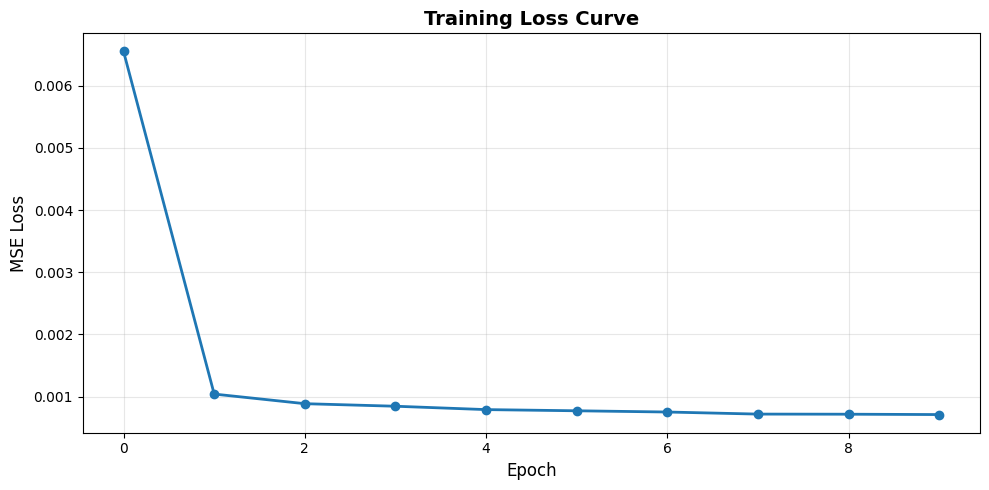


✓ Training complete!

Next steps:
1. Download the model file: dncnn_denoiser_div2k.pth
2. Use it in the inference notebook for super-resolution


In [30]:
# ============================================================
# 11. Plot Training Loss
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(history["loss"], marker='o', linewidth=2)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("MSE Loss", fontsize=12)
plt.title("Training Loss Curve", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Training complete!")
print("\nNext steps:")
print("1. Download the model file: dncnn_denoiser_div2k.pth")
print("2. Use it in the inference notebook for super-resolution")

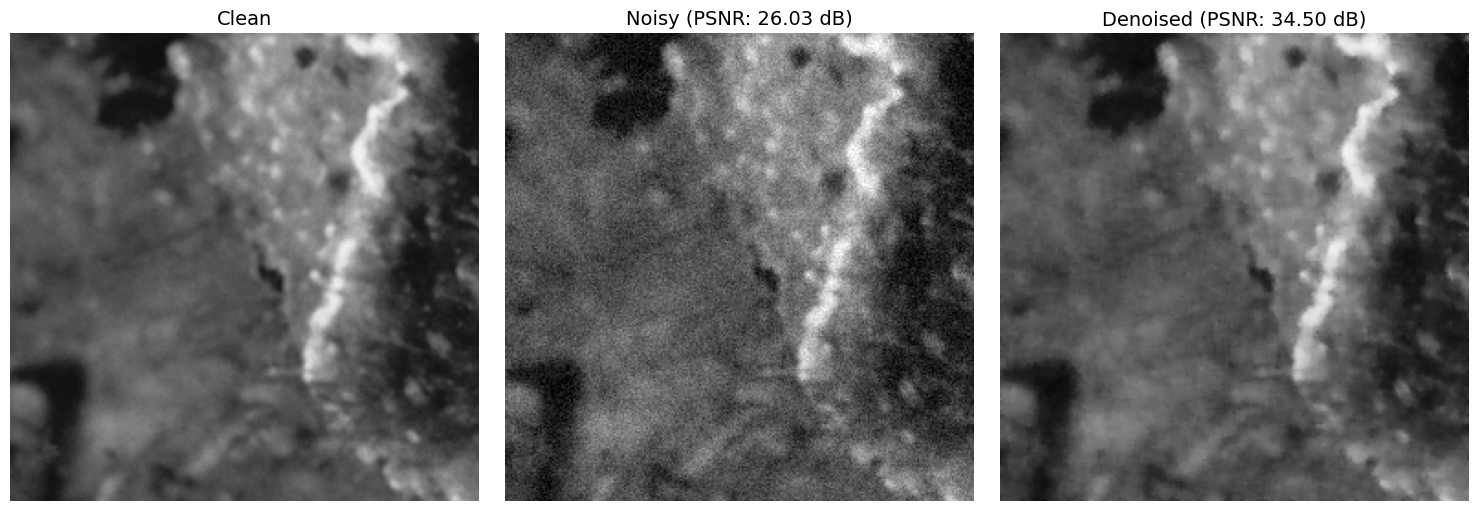


Denoising Test Results:
  Noisy PSNR: 26.03 dB
  Denoised PSNR: 34.50 dB
  Improvement: +8.46 dB


In [31]:
# ============================================================
# 12. Quick Test on Sample Image (Optional)
# ============================================================

# Test the denoiser on a sample patch
model.eval()

# Load a test image
test_img = read_image_gray(div2k_paths[0])
test_patch = test_img[:256, :256]  # Take 256x256 patch

# Add noise
test_sigma = 0.05
np.random.seed(42)
noisy_patch = np.clip(test_patch + np.random.randn(*test_patch.shape).astype(np.float32) * test_sigma, 0, 1)

# Denoise
with torch.no_grad():
    t_in = torch.from_numpy(noisy_patch).float().unsqueeze(0).unsqueeze(0).to(device)
    t_out = model(t_in)
    denoised = np.clip(t_out.squeeze().cpu().numpy(), 0, 1)

# Calculate PSNR
psnr_noisy = psnr(test_patch, noisy_patch, data_range=1.0)
psnr_denoised = psnr(test_patch, denoised, data_range=1.0)

# Visualize
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(test_patch, cmap="gray", vmin=0, vmax=1)
ax[0].set_title("Clean", fontsize=14)
ax[0].axis("off")

ax[1].imshow(noisy_patch, cmap="gray", vmin=0, vmax=1)
ax[1].set_title(f"Noisy (PSNR: {psnr_noisy:.2f} dB)", fontsize=14)
ax[1].axis("off")

ax[2].imshow(denoised, cmap="gray", vmin=0, vmax=1)
ax[2].set_title(f"Denoised (PSNR: {psnr_denoised:.2f} dB)", fontsize=14)
ax[2].axis("off")

plt.tight_layout()
plt.show()

print(f"\nDenoising Test Results:")
print(f"  Noisy PSNR: {psnr_noisy:.2f} dB")
print(f"  Denoised PSNR: {psnr_denoised:.2f} dB")
print(f"  Improvement: +{psnr_denoised - psnr_noisy:.2f} dB")